# EDA 09: Supplementary Proteomics

## Purpose

RNA is the message copied from a gene; a protein is usually the working molecule built from that message. Proteins perform most cellular jobs, so protein abundance can support an RNA-based explanation. The measurements here come from mass spectrometry, which identifies proteins by their mass and fragments.

This table maps to only 375 models and its release has not been proven to match DepMap 24Q4. It is supporting dashboard evidence, not core training or validation data.

## Considerations inherited from earlier EDA

- Join only through `model_id`; protein labels are gene/protein identifiers, not model keys.
- Missing protein abundance means not measured or not detected, not zero protein.
- Negative values are valid relative-abundance values, not negative quantities of protein.
- Stratify by lineage cautiously because coverage is only 17.81% of the master.
- Do not place this table in the core score until release provenance is verified.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option('display.max_columns',100); pd.set_option('display.max_rows',100)
sns.set_theme(style='whitegrid',context='notebook')
def find_root(start):
    for candidate in (start,*start.parents):
        if (candidate/'data'/'depmap_24Q4'/'architecture'/'model_master.csv').exists(): return candidate
    raise FileNotFoundError('Run inside the az-team25 repository.')
PROJECT_ROOT=find_root(Path.cwd().resolve()); DATA=PROJECT_ROOT/'data'/'depmap_24Q4'
master=pd.read_csv(DATA/'architecture'/'model_master.csv',low_memory=False)

path=DATA/'supplementary'/'proteomics_model.csv'
proteomics=pd.read_csv(path,low_memory=False)
protein_columns=proteomics.columns[1:].tolist()
print(f'{len(proteomics):,} models x {len(protein_columns):,} protein features')
display(proteomics.iloc[:3,:10])

375 models x 12,558 protein features


,model_id,A0AV96 (RBM47),A0AVF1 (IFT56),A0AVG3 (TSNARE1),A0AVI4 (TMEM129),A0AVK6 (E2F8),A0AVT1 (UBA6),A0JLT2 (MED19),A0JNW5 (BLTP3B),A0MZ66 (SHTN1)
0,ACH-000849,0.358567,-0.172066,NaN,NaN,NaN,-0.496842,0.267691,0.045754,0.065342
1,ACH-000441,-1.112410,0.339446,NaN,NaN,NaN,-0.395633,-0.262715,-0.414909,-0.396370
2,ACH-000248,0.855575,-0.181171,NaN,NaN,NaN,-0.284720,-0.436849,0.555351,1.550787


## Column dictionary

| Column | Plain-language meaning | Use in this project |
| --- | --- | --- |
| `model_id` | DepMap cell-line identifier. | Only automatic model-level join key. |
| `<UniProt accession> (<gene symbol>)` | Relative abundance of a protein measured by mass spectrometry. | Protein-level support for a queried gene when available. |

UniProt accessions identify proteins. Multiple protein columns can sometimes relate to one gene because proteins can have different forms. Missing values mean the protein was not quantified in that model.

## 1. Identity, coverage, and missingness

Proteomics is harder to measure than RNA and often has missing values. We check both model coverage and how often each protein was quantified.

,rows,unique_models,duplicate_models,models_not_in_master,master_coverage_pct
0,375,375,0,0,17.814727


,count,mean,std,min,25%,50%,75%,max
measured_models,12558.0,270.787227,127.277027,8.0,160.0,348.0,375.000000,375.000000
missing_pct,12558.0,27.790073,33.940541,0.0,0.0,7.2,57.333333,97.866667


,count,mean,std,min,25%,50%,75%,max
measured_proteins,375.0,9068.122667,509.833989,8096.000000,8689.000000,9072.000000,9392.000000,10425.000000
missing_pct,375.0,27.790073,4.059834,16.985189,25.211021,27.759197,30.809046,35.531136


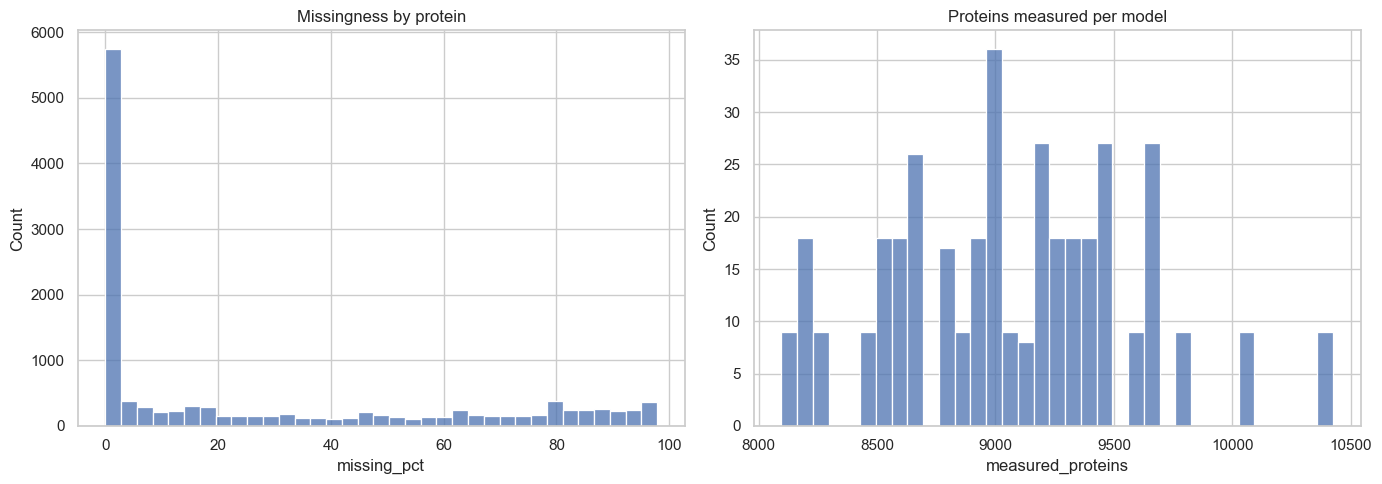

In [2]:
ids=set(proteomics['model_id']); master_ids=set(master['model_id'])
audit=pd.DataFrame([{'rows':len(proteomics),'unique_models':proteomics['model_id'].nunique(),'duplicate_models':int(proteomics['model_id'].duplicated().sum()),'models_not_in_master':len(ids-master_ids),'master_coverage_pct':100*len(ids)/len(master)}])
display(audit); assert proteomics['model_id'].is_unique and not(ids-master_ids)
values=proteomics[protein_columns]
protein_missing=pd.DataFrame({'protein':protein_columns,'measured_models':values.notna().sum().values,'missing_pct':(100*values.isna().mean()).values})
model_missing=pd.DataFrame({'model_id':proteomics['model_id'],'measured_proteins':values.notna().sum(axis=1),'missing_pct':100*values.isna().mean(axis=1)})
display(protein_missing[['measured_models','missing_pct']].describe().T); display(model_missing[['measured_proteins','missing_pct']].describe().T)
fig,axes=plt.subplots(1,2,figsize=(14,5)); sns.histplot(protein_missing['missing_pct'],bins=35,ax=axes[0]); axes[0].set_title('Missingness by protein'); sns.histplot(model_missing['measured_proteins'],bins=35,ax=axes[1]); axes[1].set_title('Proteins measured per model'); plt.tight_layout(); plt.show()

### What this means for the project

If protein B is missing in a cell line, we cannot say protein B is absent. The instrument may simply not have quantified it. Every protein-level statement must show how many models had an actual value.

## 2. Protein distributions and variable proteins

Proteins that vary across measured models may help explain selective biology, but variation can also come from missingness, lineage, or measurement differences.

,protein,mean,median,sd,measured_models,gene
6833,Q6NT46 (GAGE2A),-1.713913,-1.021716,5.373312,116,GAGE2A
10848,Q9H321 (VCX3B),-0.657092,-0.606698,4.180675,153,VCX3B
1778,P04921 (GYPC),-1.147296,-0.582707,4.170509,141,GYPC
1869,O76087 (GAGE7),-0.954770,-0.977673,3.665588,107,GAGE7
3941,P54289-4 (CACNA2D1),-0.622258,-0.089063,3.525521,214,CACNA2D1
5421,Q16655 (MLANA),-0.609890,-0.896527,3.415023,124,MLANA
3510,P49448 (GLUD2),-0.512944,-0.807983,3.356474,303,GLUD2
3386,P43360 (MAGEA6),-0.456145,-0.336743,3.272322,142,MAGEA6
390,O15479 (MAGEB2),-0.144894,-0.606220,3.267396,179,MAGEB2
564,O14602 (EIF1AY),-0.825385,-1.145816,3.239747,134,EIF1AY


,gene,unique_protein_column_found
0,TP53,True
1,BRCA1,True
2,BRCA2,True
3,ARID1A,True
4,EZH2,True
5,ALK,True
6,EGFR,True
7,KRAS,True
8,MYC,True
9,ERBB2,True


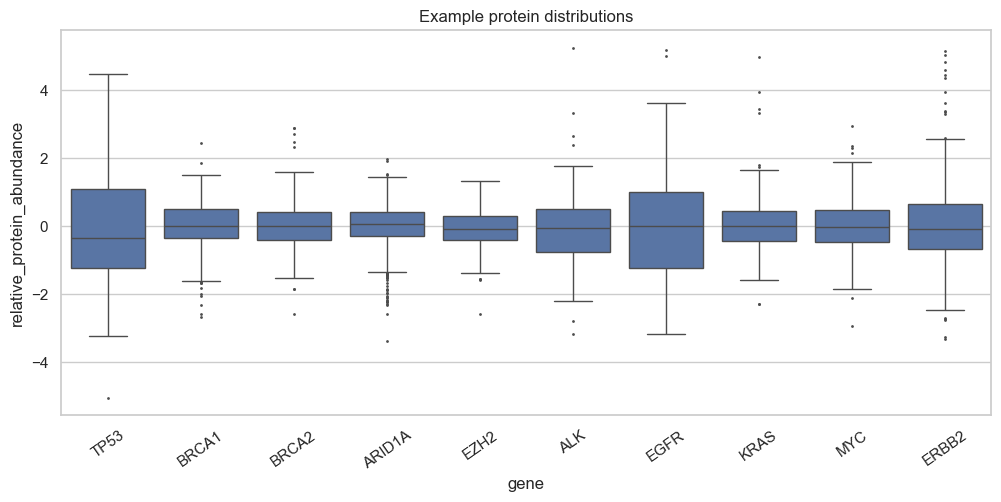

In [3]:
summary=pd.DataFrame({'protein':protein_columns,'mean':values.mean().values,'median':values.median().values,'sd':values.std().values,'measured_models':values.notna().sum().values})
summary['gene']=summary['protein'].str.extract(r'\(([^()]*)\)$')[0]
display(summary.loc[summary['measured_models'].ge(100)].nlargest(25,'sd'))
PANEL=['TP53','BRCA1','BRCA2','ARID1A','EZH2','ALK','EGFR','KRAS','MYC','ERBB2']
panel_cols={g:summary.loc[summary['gene'].eq(g),'protein'].tolist() for g in PANEL}; panel_cols={g:c[0] for g,c in panel_cols.items() if len(c)==1}
display(pd.DataFrame({'gene':PANEL,'unique_protein_column_found':[g in panel_cols for g in PANEL]}))
if panel_cols:
    panel=proteomics[['model_id',*panel_cols.values()]].rename(columns={v:k for k,v in panel_cols.items()})
    long=panel.melt('model_id',var_name='gene',value_name='relative_protein_abundance')
    plt.figure(figsize=(12,5)); sns.boxplot(data=long,x='gene',y='relative_protein_abundance',fliersize=1); plt.xticks(rotation=35); plt.title('Example protein distributions'); plt.show()

### What this means for the project

Protein abundance can strengthen a statement such as "gene B is expressed and its protein is detected." It cannot replace CRISPR dependency, and low protein abundance does not prove that disabling the gene would be harmless.

## 3. Lineage representation and decisions

Sparse coverage can make one cancer type appear more important simply because it was measured more often.

In [4]:
context=proteomics[['model_id']].merge(master[['model_id','oncotree_lineage']],on='model_id',how='left',validate='one_to_one')
lineage=context['oncotree_lineage'].fillna('Missing').value_counts().rename('proteomics_models').to_frame().join(master['oncotree_lineage'].fillna('Missing').value_counts().rename('master_models'))
lineage['coverage_pct']=100*lineage['proteomics_models']/lineage['master_models']; display(lineage.sort_values('proteomics_models',ascending=False))

,proteomics_models,master_models,coverage_pct
oncotree_lineage,,,
Lung,76,260,29.230769
Skin,33,149,22.147651
Breast,30,96,31.250000
Bowel,30,99,30.303030
Esophagus/Stomach,28,103,27.184466
Lymphoid,24,260,9.230769
Pancreas,20,68,29.411765
Ovary/Fallopian Tube,17,75,22.666667
Myeloid,16,88,18.181818


### What this means for the project

A protein pattern based on five models in one lineage is exploratory. The dashboard must show protein coverage and provenance beside the value rather than presenting it as equally reliable as release-matched RNA or CRISPR evidence.

## Decisions carried into miRNA EDA

- Keep proteomics separate from the core score and label its unverified release.
- Use only measured values and report per-protein denominators.
- Preserve UniProt and gene labels; do not merge multiple protein forms automatically.
- Treat protein abundance as supporting evidence, not dependency or interaction proof.